# SixDegrees — Pipeline Demo

Demonstrates two convergence scenarios using the live backend pipeline (no Supabase calls — all in-memory).

- **Case 1:** Eleanor and Brita have identical profiles but their interaction intensity increases across 6 frames.
- **Case 2:** Eleanor and Brita have zero interaction but Brita's profile converges toward Eleanor's across 6 frames.

In [1]:
import os
import sys

os.environ.setdefault('SUPABASE_URL', 'http://localhost')
os.environ.setdefault('SUPABASE_KEY', 'demo-key')

sys.path.insert(0, '../backend')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from models.user import UserProfile
from services.map.contracts import PipelineInput
from services.map.projector import project
from services.matching.scoring import build_similarity_matrix, apply_weights, similarity_to_distance

print('Imports OK')

Imports OK


In [2]:
ELEANOR = UserProfile(
    id='eleanor',
    nickname='Eleanor',
    city='NYC',
    state='NY',
    age=28,
    interests=['art', 'music', 'film'],
    education='bachelor',
    industry='media',
    languages=['english'],
)

BRITA_ORIGINAL = UserProfile(
    id='brita',
    nickname='Brita',
    city='Austin',
    state='TX',
    age=45,
    interests=['sports', 'finance', 'cooking'],
    education='phd',
    industry='tech',
    languages=['german', 'spanish'],
)

FRIENDS = [
    UserProfile(id='friend_01', nickname='friend_01', city='NYC', state='NY', age=27,
                interests=['art', 'music'], education='bachelor', industry='media',
                languages=['english']),
    UserProfile(id='friend_02', nickname='friend_02', city='NYC', state='NY', age=30,
                interests=['film', 'art'], education='bachelor', industry='media',
                languages=['english']),
    UserProfile(id='friend_03', nickname='friend_03', city='Brooklyn', state='NY', age=26,
                interests=['music', 'film'], education='bachelor', industry='media',
                languages=['english']),
    UserProfile(id='friend_04', nickname='friend_04', city='NYC', state='NY', age=29,
                interests=['art', 'film', 'music'], education='master', industry='media',
                languages=['english', 'french']),
    UserProfile(id='friend_05', nickname='friend_05', city='Hoboken', state='NJ', age=31,
                interests=['art', 'music'], education='bachelor', industry='entertainment',
                languages=['english']),
]

# Fixed key names: likes_count / comments_count (not like_count / comment_count)
FRIEND_INTERACTIONS = []
for f in FRIENDS:
    uid_a, uid_b = sorted(['eleanor', f.id])
    FRIEND_INTERACTIONS.append({
        'user_id_a': uid_a,
        'user_id_b': uid_b,
        'likes_count': 30,
        'comments_count': 20,
    })

import random
random.seed(0)

_cities  = ['Chicago', 'LA', 'Seattle', 'Denver', 'Miami', 'Boston', 'Portland',
             'Atlanta', 'Dallas', 'Phoenix', 'Nashville', 'San Diego']
_states  = ['IL', 'CA', 'WA', 'CO', 'FL', 'MA', 'OR', 'GA', 'TX', 'AZ', 'TN', 'CA']
_interest_pool = ['gaming', 'hiking', 'travel', 'photography', 'cooking', 'fitness',
                  'reading', 'yoga', 'finance', 'sports', 'tech', 'fashion',
                  'gardening', 'DIY', 'movies', 'theatre', 'writing', 'science']
_education_pool = ['highschool', 'bachelor', 'master', 'phd', 'associate']
_industry_pool  = ['tech', 'finance', 'healthcare', 'education', 'retail',
                   'manufacturing', 'construction', 'legal', 'consulting']
_lang_pool = ['english', 'spanish', 'french', 'mandarin', 'arabic', 'portuguese',
               'japanese', 'korean', 'german', 'italian']

PADDING_USERS = []
for k in range(94):
    city_idx = k % len(_cities)
    PADDING_USERS.append(UserProfile(
        id=f'user_{k:03d}',
        nickname=f'user_{k:03d}',
        city=_cities[city_idx],
        state=_states[city_idx],
        age=random.randint(20, 55),
        interests=random.sample(_interest_pool, k=random.randint(1, 4)),
        education=random.choice(_education_pool),
        industry=random.choice(_industry_pool),
        languages=random.sample(_lang_pool, k=random.randint(1, 3)),
    ))

total = 2 + len(FRIENDS) + len(PADDING_USERS)
print(f'Core users: Eleanor + Brita + {len(FRIENDS)} friends + {len(PADDING_USERS)} padding = {total} total')

Core users: Eleanor + Brita + 5 friends + 94 padding = 101 total


In [3]:
FRIEND_IDS = {f.id for f in FRIENDS}

DEMO_ALPHA = 0.3
DEMO_BETA  = 0.7
DEMO_IWEIGHTS = {'likes_count': 0.3, 'comments_count': 0.5}

_FRIEND_RAW = 30 * DEMO_IWEIGHTS['likes_count'] + 20 * DEMO_IWEIGHTS['comments_count']  # 19.0
DEMO_NORM = _FRIEND_RAW


def build_distance_demo(data: PipelineInput):
    """Returns (combined_dist_matrix, profile_dist, interaction_dist)."""
    profiles = data.profiles
    n = len(profiles)

    sim_matrix = build_similarity_matrix(profiles)
    weighted = apply_weights(sim_matrix)
    profile_dist = similarity_to_distance(weighted)

    interaction_map = {(r['user_id_a'], r['user_id_b']): r for r in data.interactions}
    raw_scores = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            uid_i, uid_j = profiles[i].id, profiles[j].id
            key = (min(uid_i, uid_j), max(uid_i, uid_j))
            row = interaction_map.get(key)
            if row:
                score = (row.get('likes_count', 0) * DEMO_IWEIGHTS['likes_count']
                         + row.get('comments_count', 0) * DEMO_IWEIGHTS['comments_count'])
                raw_scores[i][j] = raw_scores[j][i] = score

    normalized = np.clip(raw_scores / DEMO_NORM, 0.0, 1.0)
    interaction_dist = 1.0 - normalized
    np.fill_diagonal(interaction_dist, 0.0)

    combined = np.clip(DEMO_ALPHA * profile_dist + DEMO_BETA * interaction_dist, 0.0, 1.0)
    np.fill_diagonal(combined, 0.0)
    return combined


def plot_frame(ax, profiles, interactions, title):
    data = PipelineInput(profiles=profiles, interactions=interactions)
    dist_matrix = build_distance_demo(data)
    coords = project(dist_matrix)

    uid_to_idx = {p.id: i for i, p in enumerate(profiles)}
    eleanor_idx = uid_to_idx['eleanor']
    brita_idx   = uid_to_idx['brita']

    # Raw combined distance — monotonically decreasing, comparable across frames
    raw_dist = dist_matrix[eleanor_idx][brita_idx]

    coords = coords - coords[eleanor_idx]

    for i, p in enumerate(profiles):
        x, y = coords[i]
        if p.id == 'eleanor':
            ax.scatter(x, y, c='royalblue', marker='*', s=200, zorder=5)
        elif p.id == 'brita':
            ax.scatter(x, y, c='crimson', marker='o', s=80, zorder=4)
        elif p.id in FRIEND_IDS:
            ax.scatter(x, y, c='goldenrod', marker='^', s=60, zorder=3)
        else:
            ax.scatter(x, y, c='lightgrey', marker='.', s=20, zorder=1)

    ax.set_title(f'{title}\ncombined dist = {raw_dist:.3f}', fontsize=8.5)
    ax.set_xticks([])
    ax.set_yticks([])


print(f'DEMO_NORM = {DEMO_NORM:.1f}  (friend score — fixed normalization reference)')

DEMO_NORM = 19.0  (friend score — fixed normalization reference)


/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metri

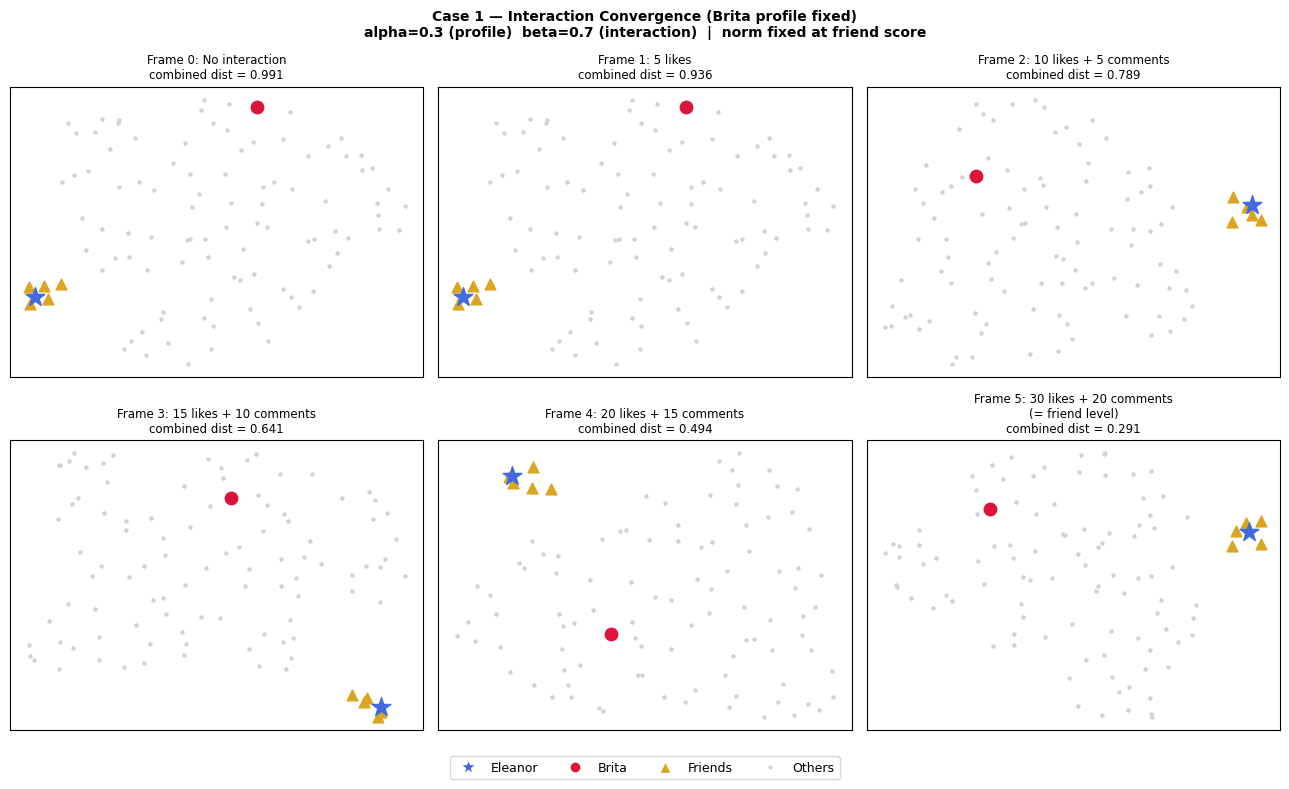

In [4]:
base_profiles = [ELEANOR, BRITA_ORIGINAL] + FRIENDS + PADDING_USERS

# Scores relative to friend level (19.0 = 100%):
# Frame 1:  5 likes           → 1.5  ( 8%)
# Frame 2: 10 likes+5 com     → 5.5  (29%)
# Frame 3: 15 likes+10 com    → 9.5  (50%)
# Frame 4: 20 likes+15 com    → 13.5 (71%)
# Frame 5: 30 likes+20 com    → 19.0 (100% = friend level)
CASE1_FRAMES = [
    ('Frame 0: No interaction',           0,   0),
    ('Frame 1: 5 likes',                  5,   0),
    ('Frame 2: 10 likes + 5 comments',   10,   5),
    ('Frame 3: 15 likes + 10 comments',  15,  10),
    ('Frame 4: 20 likes + 15 comments',  20,  15),
    ('Frame 5: 30 likes + 20 comments\n(= friend level)', 30, 20),
]

fig1, axes1 = plt.subplots(2, 3, figsize=(13, 8))
fig1.suptitle(
    'Case 1 — Interaction Convergence (Brita profile fixed)\n'
    'alpha=0.3 (profile)  beta=0.7 (interaction)  |  norm fixed at friend score',
    fontsize=10, fontweight='bold'
)

for ax, (title, likes, comments) in zip(axes1.flat, CASE1_FRAMES):
    interactions = list(FRIEND_INTERACTIONS)
    if likes > 0 or comments > 0:
        uid_a, uid_b = sorted(['eleanor', 'brita'])
        interactions.append({
            'user_id_a': uid_a,
            'user_id_b': uid_b,
            'likes_count': likes,
            'comments_count': comments,
        })
    plot_frame(ax, base_profiles, interactions, title)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='royalblue', markersize=12, label='Eleanor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',   markersize=8,  label='Brita'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='goldenrod', markersize=8,  label='Friends'),
    Line2D([0], [0], marker='.', color='w', markerfacecolor='lightgrey', markersize=8,  label='Others'),
]
fig1.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/BAEK/Code/sixDegrees/backend/venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metri

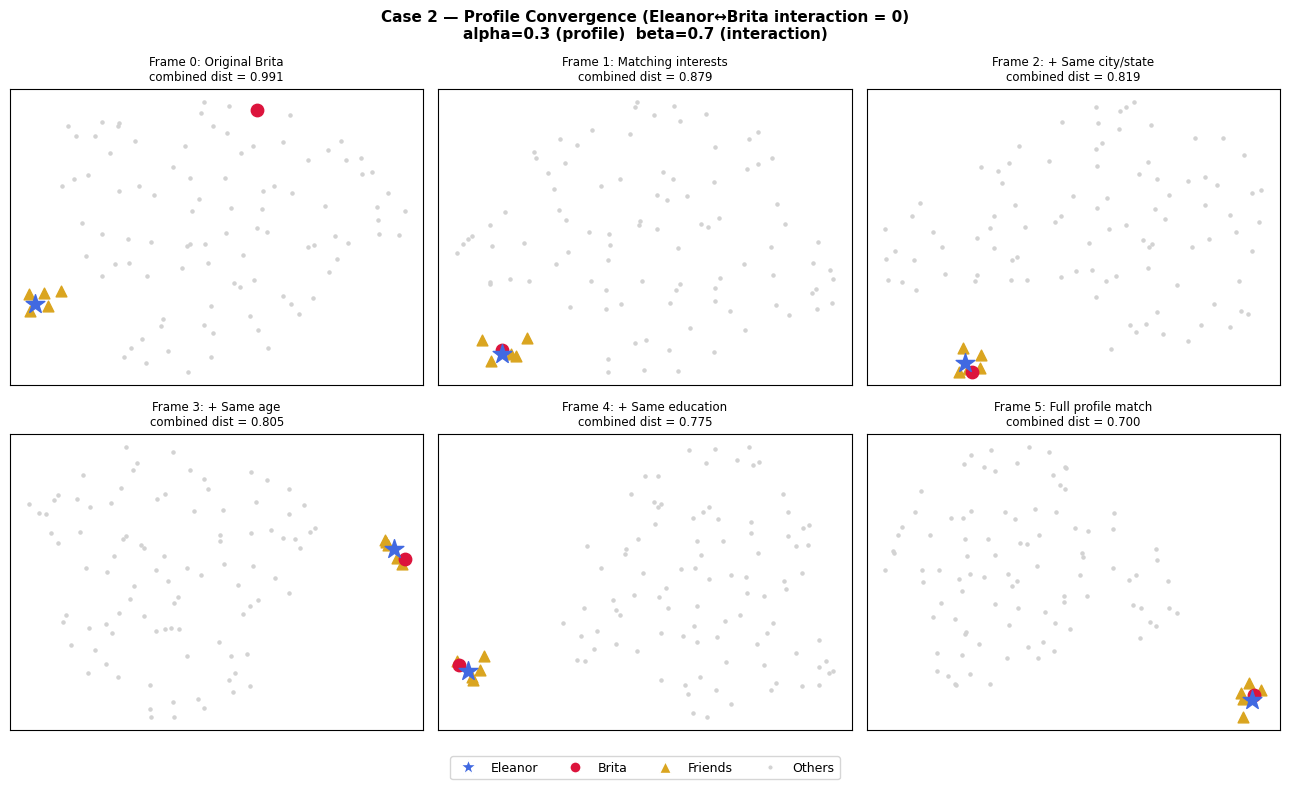

In [5]:
def make_brita(**overrides):
    base = BRITA_ORIGINAL.model_dump()
    base.update(overrides)
    return UserProfile(**base)


CASE2_BRITAS = [
    ('Frame 0: Original Brita',
     make_brita()),
    ('Frame 1: Matching interests',
     make_brita(interests=['art', 'music', 'film'])),
    ('Frame 2: + Same city/state',
     make_brita(interests=['art', 'music', 'film'], city='NYC', state='NY')),
    ('Frame 3: + Same age',
     make_brita(interests=['art', 'music', 'film'], city='NYC', state='NY', age=28)),
    ('Frame 4: + Same education',
     make_brita(interests=['art', 'music', 'film'], city='NYC', state='NY', age=28,
                education='bachelor')),
    ('Frame 5: Full profile match',
     make_brita(interests=['art', 'music', 'film'], city='NYC', state='NY', age=28,
                education='bachelor', industry='media', languages=['english'])),
]

fig2, axes2 = plt.subplots(2, 3, figsize=(13, 8))
fig2.suptitle(
    'Case 2 — Profile Convergence (Eleanor↔Brita interaction = 0)\n'
    'alpha=0.3 (profile)  beta=0.7 (interaction)',
    fontsize=11, fontweight='bold'
)

for ax, (title, brita_profile) in zip(axes2.flat, CASE2_BRITAS):
    profiles = [ELEANOR, brita_profile] + FRIENDS + PADDING_USERS
    plot_frame(ax, profiles, FRIEND_INTERACTIONS, title)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='royalblue', markersize=12, label='Eleanor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',   markersize=8,  label='Brita'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='goldenrod', markersize=8,  label='Friends'),
    Line2D([0], [0], marker='.', color='w', markerfacecolor='lightgrey', markersize=8,  label='Others'),
]
fig2.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()